# 03 — Clustering (Career Personas)

**Maps from previous project:** Notebook 03 (DBSCAN + K-Means personas)

**Input:** `data/processed/leaver_feature_store.pkl`

**Tasks:**
1. Build a numeric feature matrix from RIASEC / sector signals
2. K-Means → career personas for leavers
3. Visualise with PCA

**Personas (target labels):**
- Technical Specialist
- Hands-on Maker
- People & Care
- Creative / Commercial

**Output:** `data/processed/clustered_leavers.pkl`, `app/app_data/persona_summary.csv`

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
APP_DATA_DIR = PROJECT_ROOT / "app" / "app_data"
APP_DATA_DIR.mkdir(parents=True, exist_ok=True)

leavers = pd.read_pickle(PROCESSED_DIR / "leaver_feature_store.pkl")
print(f"Leavers: {len(leavers)}")

Leavers: 8


## 1. Build clustering matrix

Uses embedding PCA components + simple sector one-hots so clustering works even with a small synthetic cohort.

In [8]:
vectors = np.stack(leavers["vector"].values)
pca_emb = PCA(n_components=min(4, len(leavers) - 1), random_state=42)
X_emb = pca_emb.fit_transform(vectors)

SECTORS = [
    "cyber_digital", "aerospace_manufacturing", "agri_tech_food",
    "health_care", "public_sector", "creative_events",
    "construction_green", "hospitality_retail", "business_professional",
]

def sector_flags(row):
    tags = set(str(row.get("interest_sectors", "")).split("|"))
    return [1.0 if s in tags else 0.0 for s in SECTORS]

X_sec = np.array([sector_flags(r) for _, r in leavers.iterrows()])
X = np.hstack([X_emb, X_sec])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Feature matrix: {X_scaled.shape}")

Feature matrix: (8, 13)


## 2. Choose k & fit K-Means

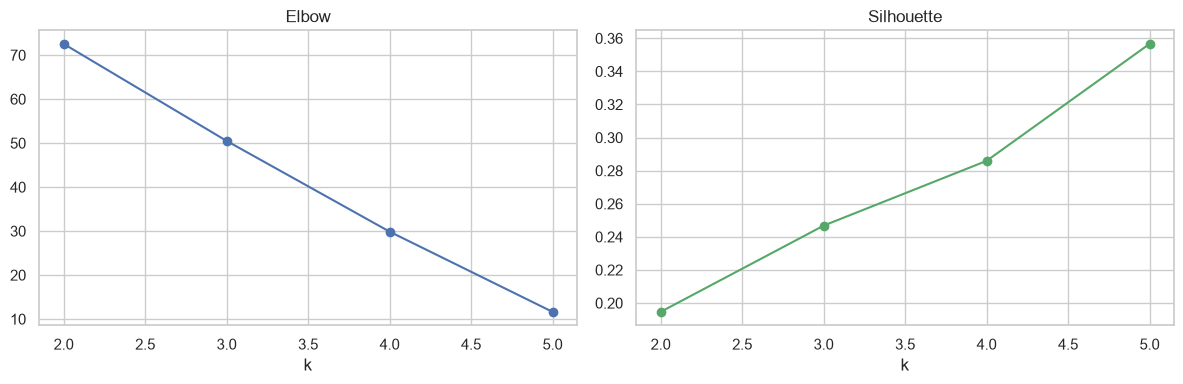

Using k=4


In [9]:
K_range = range(2, min(6, len(leavers)))
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, "bo-")
axes[0].set_title("Elbow")
axes[0].set_xlabel("k")
axes[1].plot(list(K_range), silhouettes, "go-")
axes[1].set_title("Silhouette")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

OPTIMAL_K = 4 if len(leavers) >= 4 else max(2, len(leavers) // 2)
print(f"Using k={OPTIMAL_K}")

In [10]:
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
leavers["cluster"] = kmeans.fit_predict(X_scaled)

PERSONA_NAMES = {
    0: "Technical Specialist",
    1: "Hands-on Maker",
    2: "People & Care",
    3: "Creative / Commercial",
}

# Assign labels by inspecting dominant interests in each cluster
def infer_persona(group):
    text = " ".join(group["interest_sectors"].astype(str))
    if "cyber" in text or "business_professional" in text and "creative" not in text:
        if "cyber" in text:
            return "Technical Specialist"
    if "aerospace" in text or "construction" in text:
        return "Hands-on Maker"
    if "health" in text or "public_sector" in text and "creative" not in text:
        return "People & Care"
    if "creative" in text or "hospitality" in text:
        return "Creative / Commercial"
    if "agri" in text:
        return "Hands-on Maker"
    return "Technical Specialist"

persona_map = {}
used = set()
fallback = ["Technical Specialist", "Hands-on Maker", "People & Care", "Creative / Commercial"]
for cid, group in leavers.groupby("cluster"):
    name = infer_persona(group)
    if name in used:
        for f in fallback:
            if f not in used:
                name = f
                break
    persona_map[cid] = name
    used.add(name)

leavers["persona"] = leavers["cluster"].map(persona_map)
print(leavers[["leaver_id", "persona", "interest_sectors", "dominant_riasec"]])

  leaver_id                persona  \
0      L001   Technical Specialist   
1      L002          People & Care   
2      L003         Hands-on Maker   
3      L004         Hands-on Maker   
4      L005  Creative / Commercial   
5      L006         Hands-on Maker   
6      L007   Technical Specialist   
7      L008  Creative / Commercial   

                                    interest_sectors  \
0                                      cyber_digital   
1         aerospace_manufacturing|construction_green   
2    agri_tech_food|construction_green|public_sector   
3                          health_care|public_sector   
4  business_professional|creative_events|hospital...   
5    agri_tech_food|construction_green|public_sector   
6                business_professional|cyber_digital   
7           business_professional|hospitality_retail   

              dominant_riasec  
0  Investigative|Conventional  
1      Realistic|Conventional  
2            Realistic|Social  
3         Social|Convent

## 3. PCA visualisation

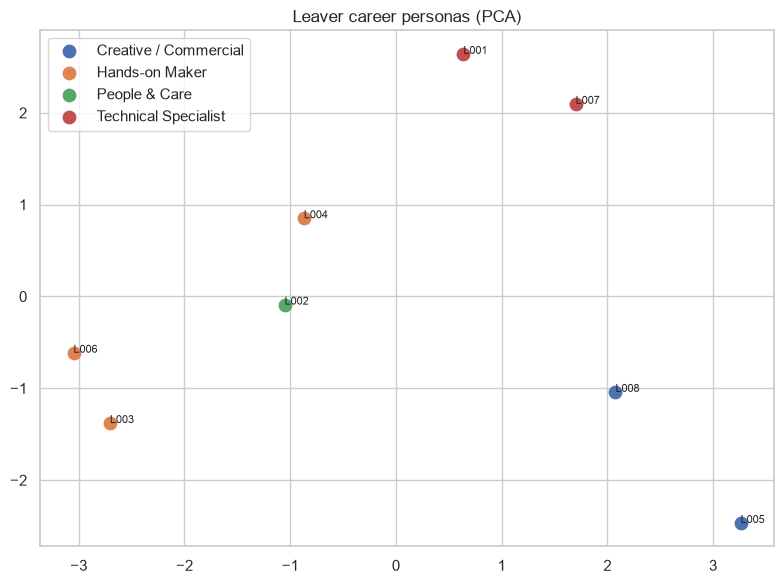

In [11]:
pca2 = PCA(n_components=2, random_state=42)
coords = pca2.fit_transform(X_scaled)

plot_df = leavers.copy()
plot_df["PC1"] = coords[:, 0]
plot_df["PC2"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
for persona, group in plot_df.groupby("persona"):
    ax.scatter(group["PC1"], group["PC2"], label=persona, s=80)
    for _, r in group.iterrows():
        ax.annotate(r["leaver_id"], (r["PC1"], r["PC2"]), fontsize=8)
ax.set_title("Leaver career personas (PCA)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Save

In [12]:
leavers.to_pickle(PROCESSED_DIR / "clustered_leavers.pkl")

summary = (
    leavers.groupby("persona")
    .agg(n=("leaver_id", "count"), example_sectors=("interest_sectors", "first"))
    .reset_index()
)
summary.to_csv(APP_DATA_DIR / "persona_summary.csv", index=False)
print(summary)
print("\nProceed to Notebook 04 — Company Recommender.")

                 persona  n                                    example_sectors
0  Creative / Commercial  2  business_professional|creative_events|hospital...
1         Hands-on Maker  3    agri_tech_food|construction_green|public_sector
2          People & Care  1         aerospace_manufacturing|construction_green
3   Technical Specialist  2                                      cyber_digital

Proceed to Notebook 04 — Company Recommender.
